In [1]:
# region Imports
import os
import sys
import torch
import numpy as np
from clustpy.deep.neural_networks.feedforward_autoencoder import FeedforwardAutoencoder

sys.path.append("/export/share/peters57dm/Verbund/deepsync/experiments/")
from helper.tracker import (
    AttractionRepellingLossTracker,
    AESyncLossTracker,
    EvaluationTracker,
)
from helper.datasets import (
    load_example,
    load_usps,
    load_htru,
    load_pendigits,
    load_optdigits,
    load_mnist,
    load_letterrecognition,
    load_cmu_faces,
    load_coil20,
    load_coil100,
    load_har,
    load_mice,
    load_synth_high,
    load_synth_low,
    load_weizmann,
    load_gaussian_blobs,
    load_cifar10,
    load_cifar100,
    load_fmnist,
    load_data,
)



In [2]:
sys.path.append("/export/share/peters57dm/Verbund/deepsync/")

from helper.utils import save_dict_as_json, load_json_as_dict

In [3]:
def load_predicted_label_estimated_k(dataname, model_i):
    results_path = f"/export/share/peters57dm/Verbund/deepsync/results/experiments/comparison406/ae_sync_loss/knn_label_assignment/{dataname}/model_0{model_i}/trackers/eval_tracker.json"
    results = load_json_as_dict(results_path)
    return np.array(results["predicted_labels"])

In [6]:
from DeepSynC.helper import (
    # label assignment
    knn_assign_unlabeled_points,
    mahalanobis_assign_unlabeled_points,
    euclidean_assign_unlabeled_points,
    knn_average_assign_unlabeled_points,
    vote_of_two_knn_methods,
    # loss functions
    attraction_repelling_loss,
    ae_sync_loss,
    # run deep sync
    deep_sync_model_ship_trueK,
    deep_sync_model_ship,
    encode_batchwise,
    find_local_core_points_same
)
from helper.deep import (
    detect_device,
    load_pretrained_model,
    get_train_and_testloader,
)

#from helper.plots import (
    #get_clust_confusion_matrix,
#)


from helper.utils import save_dict_as_json

# endregion

In [7]:
# region Exp. Definition
experiment_params = {
    "loss_funs": [
        ("ae_sync_loss", ae_sync_loss),
        # ("att_rep_loss", attraction_repelling_loss)
    ],  # number of loss functions must be equal to # number of losses trackers
    "batch_loss_trackers": [
        AESyncLossTracker,
        # AttractionRepellingLossTracker
    ],
    "evaluation_tracker": EvaluationTracker,
    "datasets": [
        #load_example,
        #load_usps,
        #load_htru,
        #load_pendigits,
        #load_optdigits,
        #load_letterrecognition,
        #load_har,
        #load_mice,
        load_mnist,
        #load_fmnist,
        #load_coil20,
        #load_coil100,
        #load_weizmann,
        # load_synth_high,
        # load_synth_low,
        # load_cifar100,
        # load_cifar10,
        # load_gaussian_blobs,
    ],
    "label_assignment_methods": [
        ("knn_label_assignment", knn_assign_unlabeled_points),
        # ("mahalanobis_label_assignment", mahalanobis_assign_unlabeled_points),
        # ("knn_average_dist_label_assignment", knn_average_assign_unlabeled_points),
        # ("vote_knn_methods", vote_of_two_knn_methods)
        # ("euclidean_label_assignment", euclidean_assign_unlabeled_points)
    ],
    "experiment_repetitions": 1,
}
assert len(experiment_params["loss_funs"]) == len(experiment_params["batch_loss_trackers"])
# Hey! that is important too. Don't go too fast my friend :)
execution_params = {
    "experiment_root_path": "/export/share/peters57dm/Verbund/deepsync/results/experiments/core_point_cluster_coverage",
    "model_name": "autoencoder.pth",
    "k": 25,
    "percent": 0.1,
    "n_check": 3,  # check for high confidence and check for early stopping.
    "learning_rate_pretrain": None,
    "learning_rate_deepsync": 1e-4,
    "pretrain_training_iterations": None,
    "clustering_training_iterations": 300,  # Switched to a max iteration of 300.
    "batch_size": 256,
    "max_embedded_dim_size": 10,
    "do_pretrain": False,
    "pretrain_loss": torch.nn.MSELoss(),
    "do_deepsync_train": True,
    "gif_duration": 300,
    "pretrained_model_path": "/export/share/peters57dm/Verbund/data/n-pretrained-models/mse_pretrained_models256-128-64",
    "AE_layers": [256, 128, 64],
    "Note": "just extracting the core point coverage",
}
# endregion

In [8]:
# region Params Loading
base_path = execution_params["experiment_root_path"]
loss_fns = experiment_params["loss_funs"]
datasets_loading_methods = experiment_params["datasets"]
loss_trackers = experiment_params["batch_loss_trackers"]
labels_assignment_methods = experiment_params["label_assignment_methods"]
k = execution_params["k"]
percent = execution_params["percent"]
n_check = execution_params["n_check"]
pretrain_lr = execution_params["learning_rate_pretrain"]
deepsync_lr = execution_params["learning_rate_deepsync"]
pretrain_n_epochs = execution_params["pretrain_training_iterations"]
clustering_n_epochs = execution_params["clustering_training_iterations"]
batch_size = execution_params["batch_size"]
max_embed_size = execution_params["max_embedded_dim_size"]
do_pretrain = execution_params["do_pretrain"]
do_deepsync_train = execution_params["do_deepsync_train"]
pretrain_loss_fn = execution_params["pretrain_loss"]
experiment_repetitions = experiment_params["experiment_repetitions"]
# device = "cuda:1"
device = detect_device()
model_name = execution_params["model_name"]
pretrained_model_path = execution_params["pretrained_model_path"]
deep_sync_model_name = "deep_sync_" + model_name
deep_sync_path = os.path.join(base_path, "deep_sync.pth")
ae_layers = execution_params["AE_layers"]
N_MODELS = 5
# endregion


In [9]:
assert len(experiment_params["loss_funs"]) == len(experiment_params["batch_loss_trackers"])
# Hey! that is important too. Don't go too fast my friend :)
execution_params = {
    "experiment_root_path": "/export/share/peters57dm/Verbund/deepsync/results/experiments/core_point_cluster_coverage",
    "model_name": "autoencoder.pth",
    "k": 25,
    "percent": 0.1,
    "n_check": 3,  # check for high confidence and check for early stopping.
    "learning_rate_pretrain": None,
    "learning_rate_deepsync": 1e-4,
    "pretrain_training_iterations": None,
    "clustering_training_iterations": 300,  # Switched to a max iteration of 300.
    "batch_size": 256,
    "max_embedded_dim_size": 10,
    "do_pretrain": False,
    "pretrain_loss": torch.nn.MSELoss(),
    "do_deepsync_train": True,
    "gif_duration": 300,
    "pretrained_model_path": "/export/share/peters57dm/Verbund/data/n-pretrained-models/mse_pretrained_models256-128-64",
    "AE_layers": [256, 128, 64],
    "Note": "just extracting the core point coverage",
}
# endregion


# region Params Loading
base_path = execution_params["experiment_root_path"]
loss_fns = experiment_params["loss_funs"]
datasets_loading_methods = experiment_params["datasets"]
loss_trackers = experiment_params["batch_loss_trackers"]
labels_assignment_methods = experiment_params["label_assignment_methods"]
k = execution_params["k"]
percent = execution_params["percent"]
n_check = execution_params["n_check"]
pretrain_lr = execution_params["learning_rate_pretrain"]
deepsync_lr = execution_params["learning_rate_deepsync"]
pretrain_n_epochs = execution_params["pretrain_training_iterations"]
clustering_n_epochs = execution_params["clustering_training_iterations"]
batch_size = execution_params["batch_size"]
max_embed_size = execution_params["max_embedded_dim_size"]
do_pretrain = execution_params["do_pretrain"]
do_deepsync_train = execution_params["do_deepsync_train"]
pretrain_loss_fn = execution_params["pretrain_loss"]
experiment_repetitions = experiment_params["experiment_repetitions"]
# device = "cuda:1"
device = detect_device()
model_name = execution_params["model_name"]
pretrained_model_path = execution_params["pretrained_model_path"]
deep_sync_model_name = "deep_sync_" + model_name
deep_sync_path = os.path.join(base_path, "deep_sync.pth")
ae_layers = execution_params["AE_layers"]
N_MODELS = 5
# endregion



In [18]:
def get_clust_confusion_matrix(gt, pred):
    # cm = confusion_matrix(gt, pred)
    # def _make_cost_m(cm):
    #     s = np.max(cm)
    #     return -cm + s
    # indexes = linear_assignment(_make_cost_m(cm))
    # js = [e[1] for e in sorted(indexes, key=lambda x: x[0])]
    # cm2 = cm[:, js]
    # return cm2
    gt_clusters = np.unique(gt)
    pred_clusters = np.unique(pred)
    conf_matrix = np.zeros((len(gt_clusters), len(pred_clusters)), dtype=int)
    for i, gt_label in enumerate(gt_clusters):
        point_labels = pred[gt == gt_label]
        labels, cluster_sizes = np.unique(point_labels, return_counts=True)
        for j, pred_label in enumerate(labels):
            conf_matrix[i, np.argwhere(pred_clusters == pred_label)[0][0]] = cluster_sizes[j]
    # Create Plot
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(conf_matrix, cmap="YlGn")
    for i in range(len(gt_clusters)):
        for j in range(len(pred_clusters)):
            ax.text(j, i, conf_matrix[i, j], ha="center", va="center", color="black")
    plt.show()
    return conf_matrix


Dataset: MNIST


/export/share/peters57dm/Verbund/deepsync/experiments/helper/deep.py:120: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(pretrained_model_path, map_lo

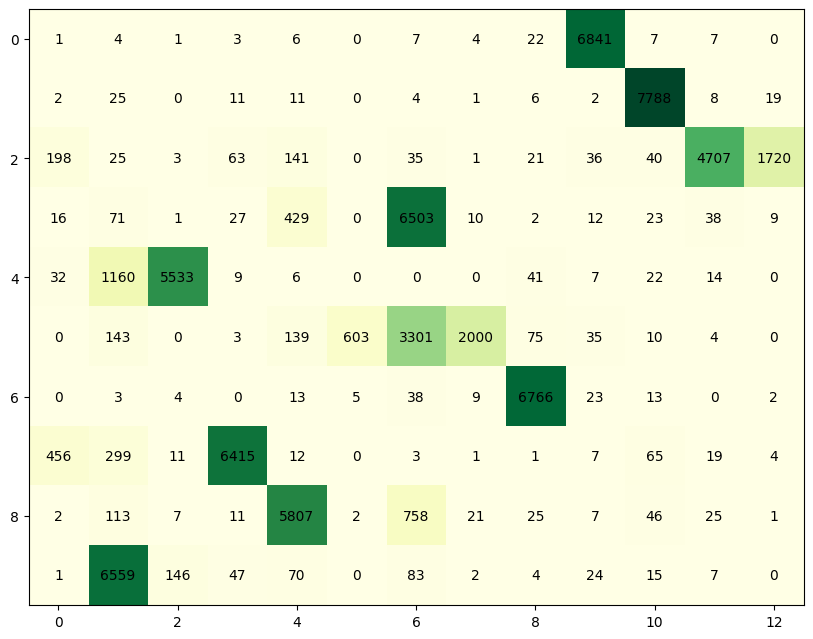

In [42]:
data, gt_labels, data_name = load_data(load_mnist)
batch_size = 256
device = detect_device()
trainloader, testloader = get_train_and_testloader(data, gt_labels, batch_size)
print(f"Dataset: {data_name}")
            
i = 1

model = FeedforwardAutoencoder(
layers=[data.shape[1], 256, 128, 64, 10]
 ).to(device)
_mpath = os.path.join(pretrained_model_path, f"pretrained_{data_name}_{i}.pth")
model = load_pretrained_model(model, _mpath, device)
#optimizer = torch.optim.Adam(model.parameters(), lr=deepsync_lr)
#trainloader, testloader = get_train_and_testloader(data, gt_labels, batch_size)



pred = load_predicted_label_estimated_k(data_name, i)


conf_matrix_MNIST = get_clust_confusion_matrix(gt_labels, pred)            

In [20]:
from scipy.optimize import linear_sum_assignment as linear_assignment
import numpy as np

def _make_cost_m(cm):
    s = np.max(cm)
    return (- cm + s)

In [21]:
cm = conf_matrix_MNIST
indexes = linear_assignment(_make_cost_m(cm))
js = [e[1] for e in sorted(indexes, key=lambda x: x[0])]
cm2 = cm[:, js]

In [14]:
import seaborn as sn

In [43]:
#order = np.argmax(conf_matrix_MNIST, 1)
#print(order)
#[0,11,12,13,8,7,9,4,1,5,6,10,2,3]
order = [0,9,10,11,12,6,2,7,5,8,3,4,1]
new_CM = conf_matrix_MNIST[:,order]


<Axes: >

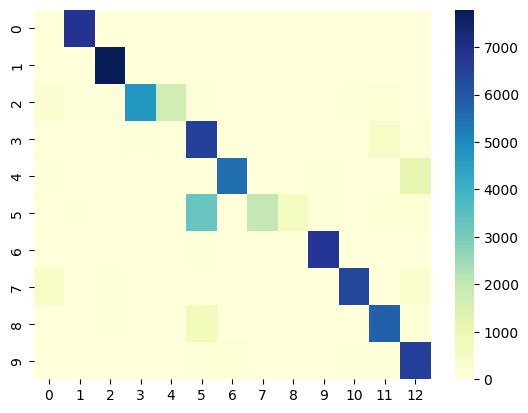

In [ ]:
sn.heatmap(new_CM,  cmap="YlGn",annot=False)
#cmap="YlGn"

In [39]:
print(np.unique(gt_labels))

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


In [ ]:
from helper.deep import encode_batchwise, get_train_and_testloader

In [17]:
import matplotlib.pyplot as plt
import torchvision
def denormalize(tensor: torch.Tensor, mean: float = 0.1307, std: float = 0.3081) -> torch.Tensor:
    """
    This applies an inverse z-transformation and reshaping to visualize
    the mnist images properly.
    """
    pt_std = torch.as_tensor(std, dtype=torch.float32, device=tensor.device)
    pt_mean = torch.as_tensor(mean, dtype=torch.float32, device=tensor.device)
    return (tensor.mul(pt_std).add(pt_mean).view(-1, 1, 28, 28) * 255).int().detach()


def plot_images(images: torch.Tensor, pad: int = 0):
    """Aligns multiple images on an N by 10 grid"""

    def imshow(img):
        plt.figure(figsize=(10, 20))
        npimg = img.numpy()
        npimg = np.array(npimg)
        plt.axis("off")
        plt.imshow(np.transpose(npimg, (1, 2, 0)), vmin=0, vmax=1)

    plt.imshow(torchvision.utils.make_grid(images, pad_value=255, normalize=False, padding=pad, nrow=10))
    plt.show()

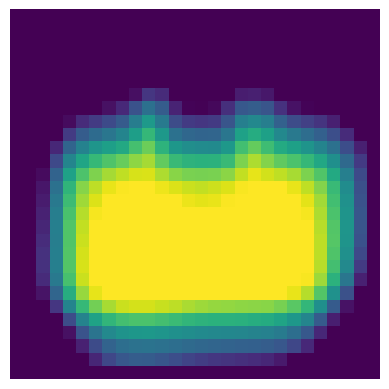

In [ ]:
mean_4 = torch.mean(data[gt_labels==8],0)
import math
sqrt_of_data = int(math.sqrt(data.shape[1]))
random_img = mean_4.numpy().reshape((sqrt_of_data, sqrt_of_data))
plt.imshow(random_img, vmin=0, vmax=1)
plt.axis('off')
plt.show()

In [84]:
trainloader,testloader = get_train_and_testloader(data, gt_labels,batch_size)
embedded_data, embedded_labels = encode_batchwise(testloader,model,device)

In [85]:
embedded_data

array([[ 8.490067  ,  3.2214103 ,  3.7273304 , ...,  0.88226855,
        13.191958  ,  0.17626302],
       [-6.361541  , -3.3757453 ,  1.9250318 , ..., -3.3446357 ,
         0.92549694, -6.6055164 ],
       [-3.4602895 , -2.1471705 , -0.94112796, ..., -0.32818124,
         2.8633993 , -1.1563741 ],
       ...,
       [-3.1808727 , -2.8570065 , -7.886483  , ...,  0.41379744,
         7.424076  , -0.21262355],
       [-6.302949  , -4.02877   , -0.4162287 , ...,  3.893211  ,
         3.5610409 , -2.9955335 ],
       [ 2.5631464 , -1.2926975 ,  1.7197884 , ...,  1.0257691 ,
         5.1622677 ,  0.8698751 ]], dtype=float32)

In [92]:
embedded_mean = np.mean(embedded_data[gt_labels==8],0).reshape(-1)
embedded_mean_torch = torch.tensor(embedded_mean)
mean_4 = model.decode(embedded_mean)
sqrt_of_data = int(math.sqrt(data.shape[1]))
random_img = mean_4.numpy().reshape((sqrt_of_data, sqrt_of_data))
plt.imshow(random_img, vmin=0, vmax=1)
plt.axis('off')
plt.show()

IndexError: tuple index out of range

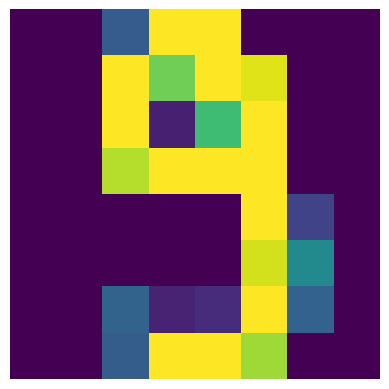

In [42]:
mean_4 = torch.mean(data[pred==4],0)
random_img = mean_4.numpy().reshape((sqrt_of_data, sqrt_of_data))
plt.imshow(random_img, vmin=0, vmax=1)
plt.axis('off')
plt.show()

In [9]:
data_9 = data[pred==-1]

In [44]:
data_9

tensor([[-0.8144, -0.8144, -0.6486,  ..., -0.8144, -0.8144, -0.8144],
        [-0.8144, -0.8144, -0.6486,  ..., -0.3169, -0.8144, -0.8144],
        [-0.8144, -0.8144,  0.6780,  ...,  1.8389,  1.8389,  1.8389],
        ...,
        [-0.8144, -0.8144, -0.8144,  ..., -0.8144, -0.8144, -0.8144],
        [-0.8144, -0.8144, -0.8144,  ..., -0.8144, -0.8144, -0.8144],
        [-0.8144, -0.8144, -0.8144,  ..., -0.4828, -0.8144, -0.8144]])

[1943 1963 4831  214   44 4350 4749 1851 4739 1435]
tensor(9.)
(8, 8)


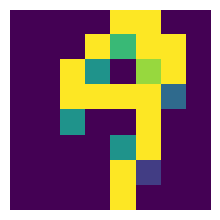

tensor(9.)
(8, 8)


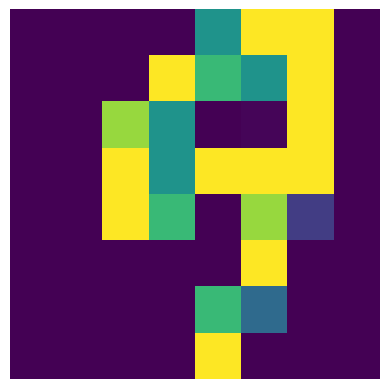

tensor(1.)
(8, 8)


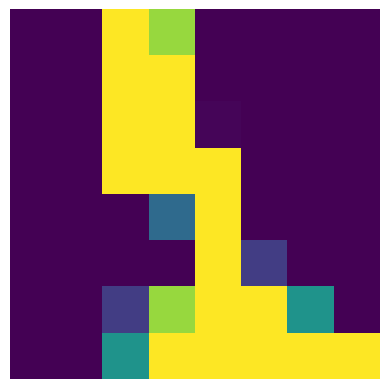

tensor(9.)
(8, 8)


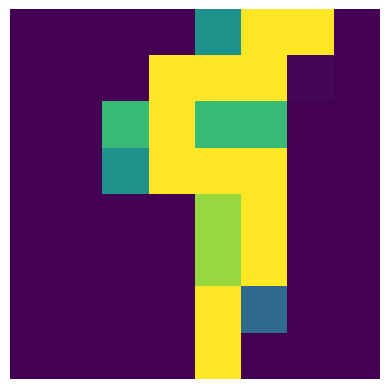

tensor(9.)
(8, 8)


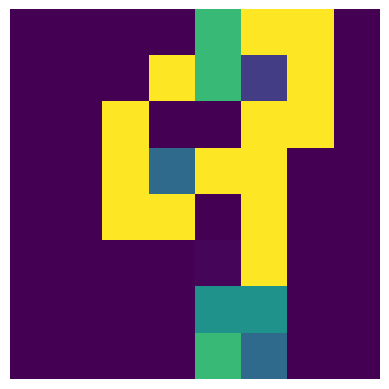

tensor(1.)
(8, 8)


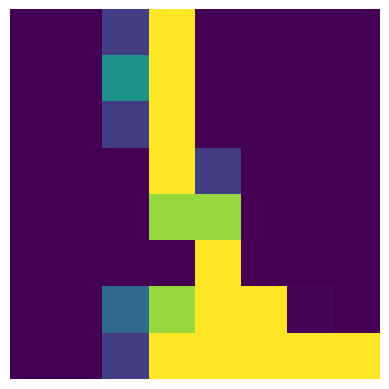

tensor(1.)
(8, 8)


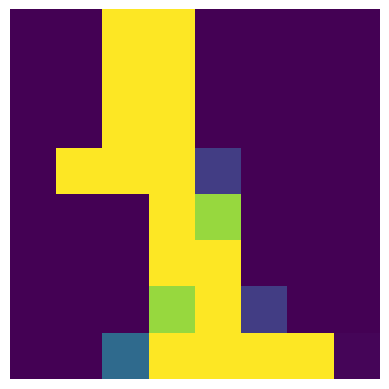

tensor(9.)
(8, 8)


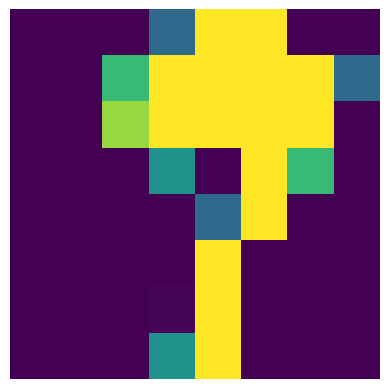

tensor(1.)
(8, 8)


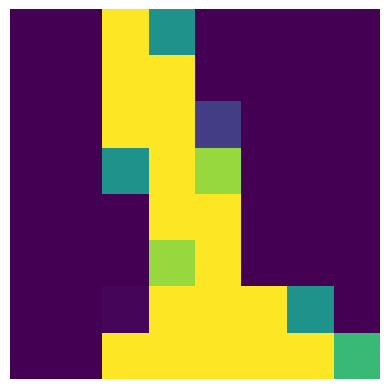

tensor(9.)
(8, 8)


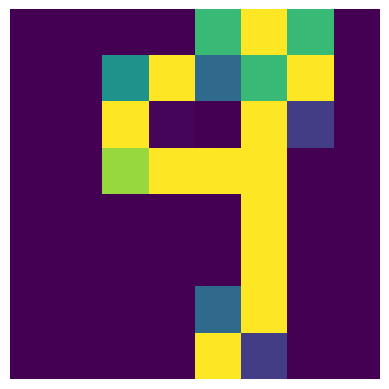

In [14]:
import math
fig=plt.figure(figsize=(15, 6))
sqrt_of_data = int(math.sqrt(data_9.shape[1]))
ids_in_cluster = np.argwhere(pred == -1).reshape(-1,)
#print(ids_in_cluster)
number_of_examples = min(10, len(ids_in_cluster))
random_image_ids = np.random.choice(ids_in_cluster, number_of_examples, replace=False)
#random_image_ids = [4542  214 4739 4538 4588 4419 4500 3714 2077 4409] optdigits outliers model 0
print(random_image_ids)
for j, random_img_id in enumerate(random_image_ids):
    random_img = data.numpy()[random_img_id].reshape((sqrt_of_data, sqrt_of_data))
    print(gt_labels[random_img_id])
    print(random_img.shape)
    fig.add_subplot(2, 5, j + 1)
    plt.imshow(random_img, vmin=0, vmax=1)
    plt.axis('off')
    plt.show()